In [3]:
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.decomposition import PCA
from scipy.stats import ks_2samp, linregress, median_abs_deviation
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


In [4]:
engine = create_engine(URL(
    account       = "UHG-UHGDWAAS",
    user          = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role          = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse     = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database      = "VING_PRD_TREND_DB",
    schema        = "TMP_1M"
))

In [5]:
# hospital_group x market aggregation — MNR FFS, 2025
df = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(*) as case_count_2025
        , sum(a.initialfulladr_cases) as initial_adr_cnt_2025
        , sum(a.persistentfulladr_cases) as persistent_adr_cnt
        , sum(a.p2p_full_ovtn) as p2p_ovrtn_cnt
        , sum(a.appeal_ovrtn_ind) as appeal_ovrtn_cnt
        , sum(a.mcr_ovtrn_ind) as mcr_ovrtn_cnt
        , sum(a.icm_md_reviewed_ind) as md_reviewed_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand in ('M&R', 'C&S')
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and fin_brand = 'M&R'
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month between '202501' and '202512'
        and d.collection is not null
    group by 1, 2
    having count(*) >= 30
""", engine)
print(f"Core (2025): {df.shape}")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lZLNbuIwFEZfJfKskzgZQsECKgplStUfBKFTdTNybAesOnbG12natx8TitRZtFIXkSLnfM6xvzs6f61U8CIsSKPHKIkwCoRmhku9G6NtvggHKABHNafKaDFGbwLQ%2BWQEtFI1mTZur9fibyPABX4jDaT7MEaN1cRQkEA0rQQQx8hmentD0giT2hpnmFHoQ%2BTrBAUQ1nnDU4SD9Hp752oSx23bRu3PyNhdnGKMYzyMPXVAfpz4V3%2BmT%2Fgkxr0D7wmPr97dLqQ%2BXsFXWsURAnKV56twdb%2FJUTA9qc6MhqYSdiPsi2Riu745CoA3aPa70D%2B8pRT%2B7GkE2rSlos%2BCmapunN8z8m9xKXiszE76Yy%2FnY1Q%2FS36ZmN8X22tzOyuns3vgq%2FXlY5Fc12awuHtqf2U0bx2fXfUf5wOGgodTr%2Bmh1yVAI5b60KbzSzjth7gfJlmeZCTpkeQsSnH2hIK5b1Nq6rrkSbnziCrJrAFTOqOV1KKz5AXOSspoyAYpDXvFkIfFkGUhLvu9on%2BWZb00iQ8dp%2Bg4N6QTsZPv3cYo%2Fph9H8A738lyvjJKsrdgYWxF3eeVJVHSrUgelh1KREWlmnJuBYCvTinTzqygzs%2B5s41A8eT41%2F8nffIP&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ7L2QH1ABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEEGn4wcJFURXbZS7O%2BhNXeIAAACQ7000QgEPEZs5o8

In [6]:
# member_appeal only exists from 202601 onward — separate pull
df_ma = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(*) as case_count_2026
        , sum(a.initialfulladr_cases) as initial_adr_cnt_2026
        , sum(a.member_appeal_ind) as member_appeal_cnt
        , sum(a.member_appeal_ovtn_ind) as member_appeal_ovtn_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand in ('M&R', 'C&S')
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and fin_brand = 'M&R'
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month >= '202601'
        and d.collection is not null
    group by 1, 2
    having sum(a.initialfulladr_cases) >= 10
""", engine)
print(f"Member appeal (202601+): {df_ma.shape}")

Member appeal (202601+): (979, 6)


In [7]:
# monthly grain for trend detection (Section F) — 202301 onward
df_monthly = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , a.hce_admit_month
        , count(*) as case_count
        , sum(a.initialfulladr_cases) as initial_adr_cnt
        , sum(a.persistentfulladr_cases) as persistent_adr_cnt
        , sum(a.p2p_full_ovtn) as p2p_ovrtn_cnt
        , sum(a.appeal_ovrtn_ind) as appeal_ovrtn_cnt
        , sum(a.mcr_ovtrn_ind) as mcr_ovrtn_cnt
        , sum(a.icm_md_reviewed_ind) as md_reviewed_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand in ('M&R', 'C&S')
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and fin_brand = 'M&R'
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month between '202301' and '202512'
        and d.collection is not null
    group by 1, 2, 3
""", engine)
engine.dispose()
print(f"Monthly (202301-202512): {df_monthly.shape}")

Monthly (202301-202512): (49166, 10)


In [8]:
z = 1.96
p_adr = df["initial_adr_cnt_2025"].sum() / df["case_count_2025"].sum()
p_ovtn = df["p2p_ovrtn_cnt"].sum() / df["initial_adr_cnt_2025"].sum()

margin_adr = z * np.sqrt(p_adr * (1 - p_adr) / 30)
margin_ovtn = z * np.sqrt(p_ovtn * (1 - p_ovtn) / 10)

print(f"Population ADR rate: {p_adr:.1%}")
print(f"At n = 50 cases, ADR rate could bounce by: ±{margin_adr:.1%}")
print(f"")
print(f"Population P2P overturn rate: {p_ovtn:.1%}")
print(f"At n = 25 ADRs, overturn rate could bounce by: ±{margin_ovtn:.1%}")

Population ADR rate: 21.8%
At n = 50 cases, ADR rate could bounce by: ±14.8%

Population P2P overturn rate: 36.7%
At n = 25 ADRs, overturn rate could bounce by: ±29.9%


In [9]:
# left_join member appeal onto core, fill missing counts with 0
df = df.merge(df_ma, on = ["hospital_group", "fin_market"], how = "left")

count_cols = ["case_count_2025", "initial_adr_cnt_2025", "persistent_adr_cnt", "p2p_ovrtn_cnt",
              "appeal_ovrtn_cnt", "mcr_ovrtn_cnt", "md_reviewed_cnt",
              "case_count_2026", "member_appeal_cnt", "initial_adr_cnt_2026"]
df[count_cols] = df[count_cols].fillna(0)

# eligibility: enough volume for the rates to mean something
df = df.query("case_count_2025 >= 30 and initial_adr_cnt_2025 >= 10 and initial_adr_cnt_2026 >= 10").copy()
print(f"After merge + eligibility filter: {df.shape}")

After merge + eligibility filter: (939, 13)


In [10]:
# empirical Bayes shrinkage: adjusted = (numerator + k * global_rate) / (denominator + k)
# k = 50 pulls hospitals with tiny rates/case counts toward the population rate so tiny samples don't 
# produce extreme rates
# This adjustments don't affect larger hospitals as they already have larger numerators and denominators

k = 50

# population-level rates (the "prior" each hospital gets pulled toward)
g_initial_adr_2025 = df["initial_adr_cnt_2025"].sum() / df["case_count_2025"].sum()
g_persistent_adr   = df["persistent_adr_cnt"].sum()   / df["case_count_2025"].sum()
g_p2p_overturn     = df["p2p_ovrtn_cnt"].sum()         / df["initial_adr_cnt_2025"].sum()
g_appeal_overturn  = df["appeal_ovrtn_cnt"].sum()       / df["initial_adr_cnt_2025"].sum()
g_mcr_overturn     = df["mcr_ovrtn_cnt"].sum()          / df["initial_adr_cnt_2025"].sum()
g_md_review        = df["md_reviewed_cnt"].sum()        / df["case_count_2025"].sum()
g_member_appeal    = df["member_appeal_cnt"].sum()      / df["initial_adr_cnt_2026"].sum()
g_initial_adr_2026 = df["initial_adr_cnt_2026"].sum()  / df["case_count_2026"].sum()

# like mutate() — one block, every adjusted rate
df = (
    df
    .assign(
        initial_adr_rate_2025 = lambda x: (x.initial_adr_cnt_2025 + k * g_initial_adr_2025) / (x.case_count_2025 + k),
        persistent_adr_rate   = lambda x: (x.persistent_adr_cnt   + k * g_persistent_adr)   / (x.case_count_2025 + k),
        p2p_overturn_rate     = lambda x: (x.p2p_ovrtn_cnt         + k * g_p2p_overturn)     / (x.initial_adr_cnt_2025 + k),
        appeal_overturn_rate  = lambda x: (x.appeal_ovrtn_cnt       + k * g_appeal_overturn)  / (x.initial_adr_cnt_2025 + k),
        mcr_overturn_rate     = lambda x: (x.mcr_ovrtn_cnt          + k * g_mcr_overturn)     / (x.initial_adr_cnt_2025 + k),
        md_review_rate        = lambda x: (x.md_reviewed_cnt        + k * g_md_review)        / (x.case_count_2025 + k),
        member_appeal_rate    = lambda x: (x.member_appeal_cnt      + k * g_member_appeal)    / (x.initial_adr_cnt_2026 + k),
        initial_adr_rate_2026 = lambda x: (x.initial_adr_cnt_2026  + k * g_initial_adr_2026) / (x.case_count_2026 + k),
        # log-volume features — lets IF tell "weird behavior" apart from "tiny sample"
        log_case_count_2025      = lambda x: np.log1p(x.case_count_2025),
        log_initial_adr_cnt_2025 = lambda x: np.log1p(x.initial_adr_cnt_2025),
        log_initial_adr_cnt_2026 = lambda x: np.log1p(x.initial_adr_cnt_2026)
    )
)

# the feature lists used everywhere below
rate_kpi = ["initial_adr_rate_2025", "persistent_adr_rate", "p2p_overturn_rate",
            "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
            "member_appeal_rate", "initial_adr_rate_2026"]
iso_kpi = ["log_case_count_2025", "log_initial_adr_cnt_2025", "log_initial_adr_cnt_2026"] + rate_kpi

print(f"Shape: {df.shape}")

Shape: (939, 24)


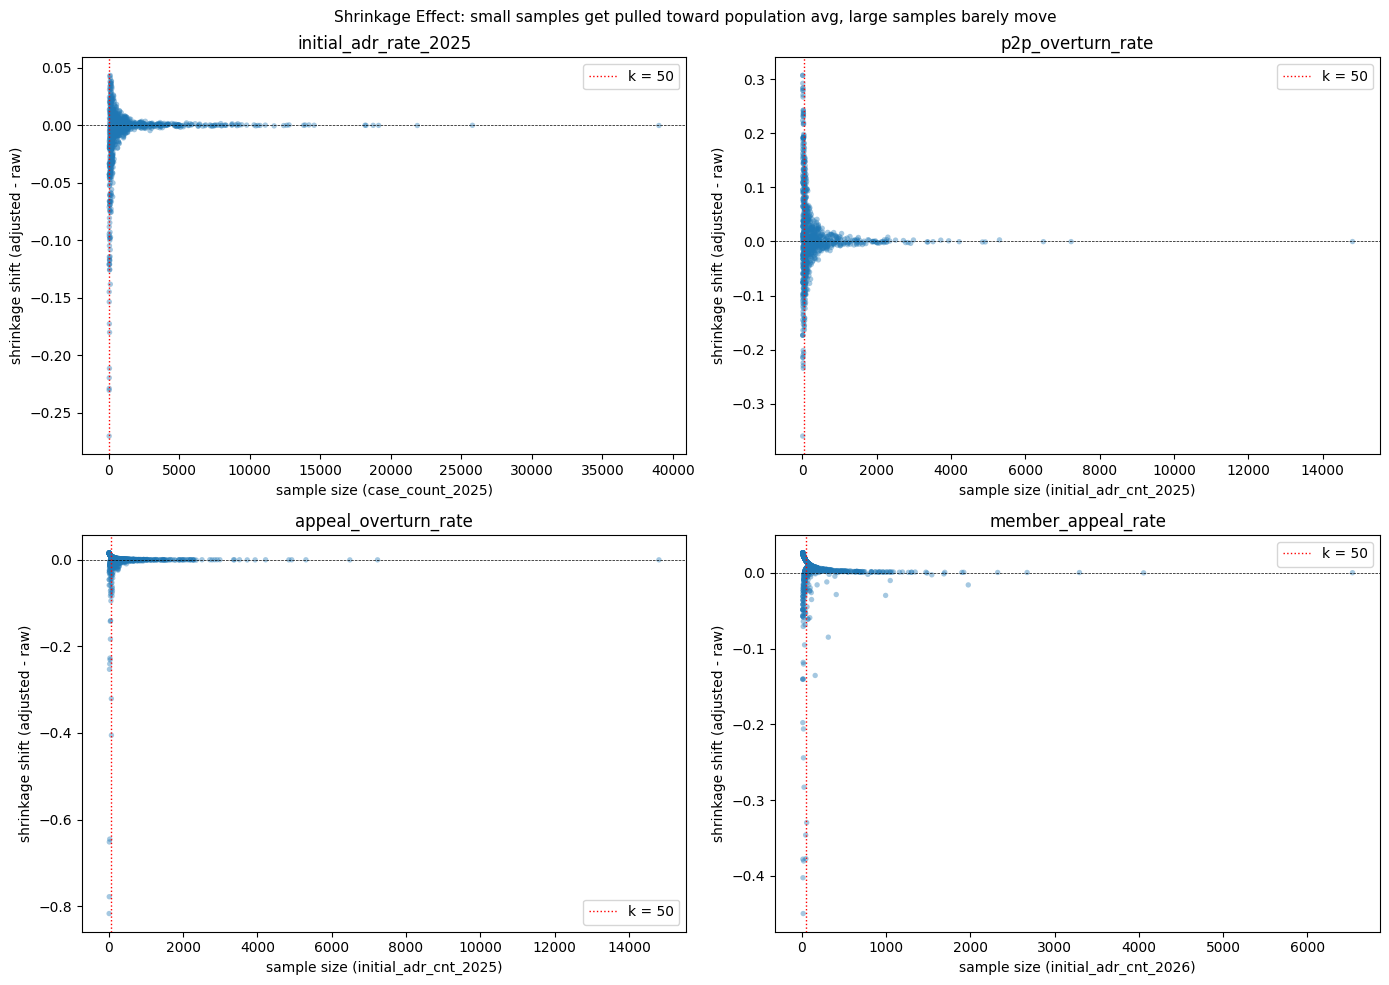

In [11]:
# visualize how shrinkage affects rates across sample sizes
# x-axis = denominator (sample size), y-axis = how much the rate moved

fig, axes = plt.subplots(2, 2, figsize = (14, 10))

examples = [
    ("initial_adr_rate_2025", "initial_adr_cnt_2025", "case_count_2025", g_initial_adr_2025),
    ("p2p_overturn_rate", "p2p_ovrtn_cnt", "initial_adr_cnt_2025", g_p2p_overturn),
    ("appeal_overturn_rate", "appeal_ovrtn_cnt", "initial_adr_cnt_2025", g_appeal_overturn),
    ("member_appeal_rate", "member_appeal_cnt", "initial_adr_cnt_2026", g_member_appeal),
]

for ax, (rate_col, num_col, denom_col, global_rate) in zip(axes.flat, examples):
    raw_rate = df[num_col] / df[denom_col]
    shrunk_rate = df[rate_col]
    shift = shrunk_rate - raw_rate
    denom = df[denom_col]

    ax.scatter(denom, shift, alpha = 0.4, s = 15, edgecolors = "none")
    ax.axhline(0, color = "black", linewidth = 0.5, linestyle = "--")
    ax.axvline(k, color = "red", linewidth = 1, linestyle = ":", label = f"k = {k}")
    ax.set_xlabel(f"sample size ({denom_col})")
    ax.set_ylabel("shrinkage shift (adjusted - raw)")
    ax.set_title(rate_col)
    ax.legend()

plt.suptitle("Shrinkage Effect: small samples get pulled toward population avg, large samples barely move", fontsize = 11)
plt.tight_layout()
plt.show()

In [12]:
df[rate_kpi].describe().round(4)

,initial_adr_rate_2025,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,member_appeal_rate,initial_adr_rate_2026
count,939.0000,939.0000,939.0000,939.0000,939.0000,939.0000,939.0000,939.0000
mean,0.2556,0.1358,0.3586,0.0218,0.0281,0.5753,0.0275,0.2719
std,0.0895,0.0589,0.1044,0.0373,0.0193,0.1512,0.0468,0.0826
min,0.0024,0.0007,0.0078,0.0007,0.0028,0.0029,0.0025,0.0114
25%,0.1996,0.0959,0.2871,0.0076,0.0157,0.5002,0.0140,0.2147
50%,0.2499,0.1293,0.3672,0.0121,0.0226,0.6015,0.0203,0.2711
75%,0.3117,0.1664,0.4284,0.0205,0.0343,0.6827,0.0259,0.3237
max,0.5890,0.4072,0.6792,0.5948,0.1627,0.8641,0.6620,0.5563


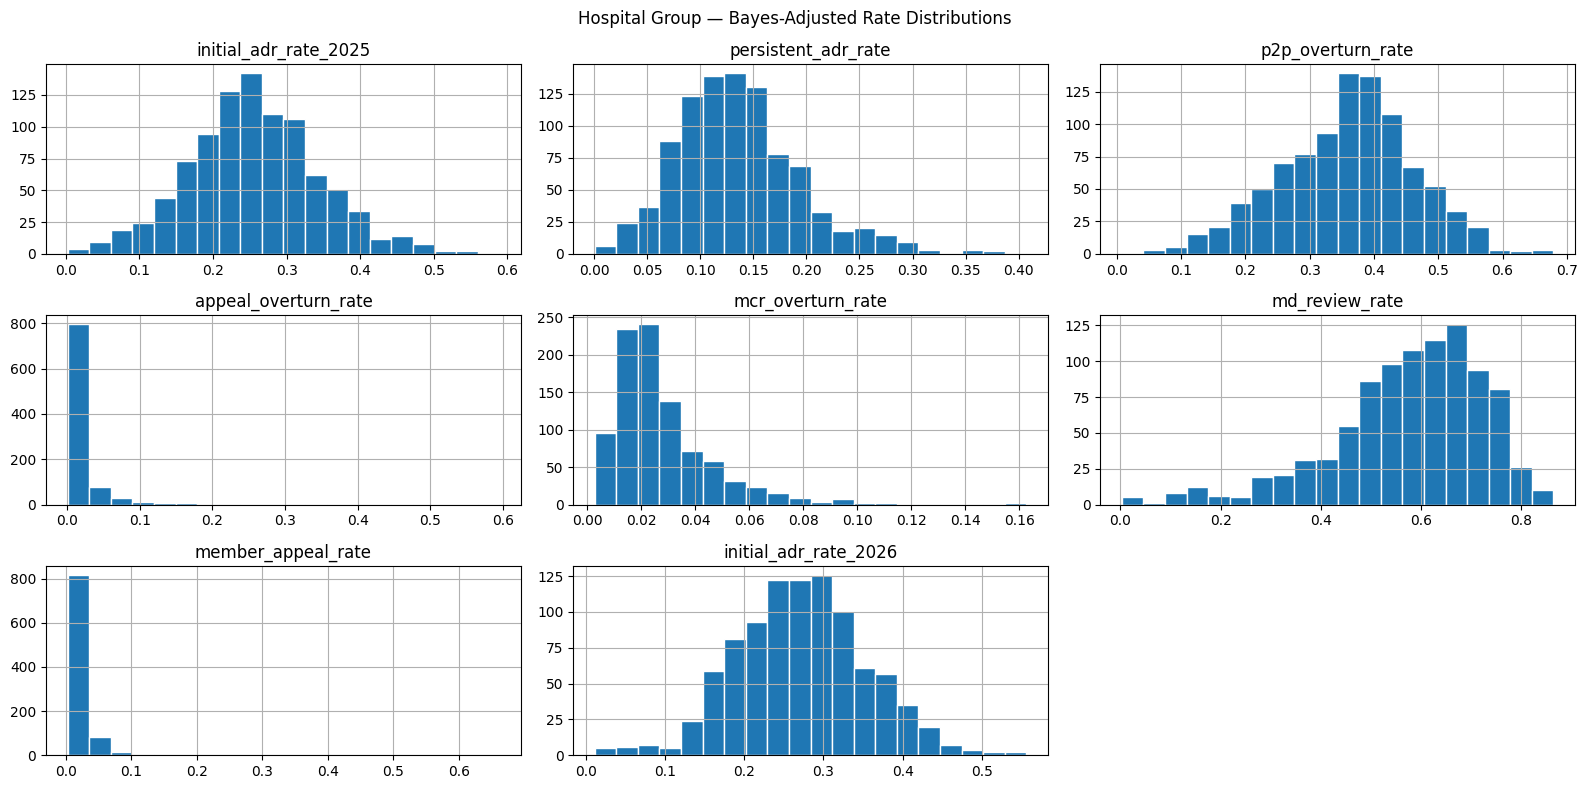

In [13]:
df[rate_kpi].hist(bins = 20, figsize = (16, 8), edgecolor = "white")
plt.suptitle("Hospital Group — Bayes-Adjusted Rate Distributions")
plt.tight_layout()
plt.show()

## Section A — National Isolation Forest

Same model as the original notebook: IF on the Bayes-adjusted rates + log volumes.
Flags the ~5% most unusual hospital groups nationally.

In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(df[iso_kpi])

iso = IsolationForest(contamination = 0.05, n_estimators = 300, random_state = 42)
iso.fit(X)

df = (
    df
    .assign(
        anomaly_score = iso.decision_function(X),
        anomaly_flag  = iso.predict(X) == -1
    )
)
df["anomaly_rank"] = df["anomaly_score"].rank(method = "dense").astype(int)

print(f"Flagged nationally: {df['anomaly_flag'].sum()} of {len(df)}")

Flagged nationally: 47 of 939


In [15]:
# MAD z-scores — robust version of z-scores (median/MAD instead of mean/SD)
# used only to explain WHY a hospital was flagged, not as model input
for col in iso_kpi:
    med = df[col].median()
    mad = median_abs_deviation(df[col], scale = 1.0) * 1.4826  # 1.4826 makes MAD ~ SD
    df[col + "_z"] = (df[col] - med) / mad if mad > 0 else 0

z_cols = [col + "_z" for col in iso_kpi]

# the driver = the feature with the biggest |z| for each hospital
df = (
    df
    .assign(
        driver    = lambda x: x[z_cols].abs().idxmax(axis = 1).str.removesuffix("_z"),
        z_score   = lambda x: x[z_cols].apply(lambda r: r[r.abs().idxmax()], axis = 1),
        direction = lambda x: np.where(x.z_score > 0, "high", "low"),
        reason    = lambda x: np.where(x.anomaly_flag, x.driver + " (" + x.direction + ")", "")
    )
)

# when the driver is a log feature, report the raw count instead (easier to read)
df["driver_raw"] = df["driver"].replace({
    "log_case_count_2025":      "case_count_2025",
    "log_initial_adr_cnt_2025": "initial_adr_cnt_2025",
    "log_initial_adr_cnt_2026": "initial_adr_cnt_2026"
})

# look up each hospital's own value for its driver column, and the population median
medians = df[rate_kpi + ["case_count_2025", "initial_adr_cnt_2025", "initial_adr_cnt_2026"]].median()
df["driver_value"]      = df.apply(lambda r: r[r["driver_raw"]], axis = 1)
df["driver_pop_median"] = df["driver_raw"].map(medians)
df["driver_dev"]        = (df["driver_value"] - df["driver_pop_median"]) / df["driver_pop_median"]

print("Drivers computed.")

Drivers computed.


In [16]:
# flagged hospitals, most anomalous first
(
    df
    .query("anomaly_flag == True")
    .sort_values("anomaly_score")
    [["hospital_group", "fin_market", "case_count_2025", "initial_adr_cnt_2025",
      *rate_kpi, "anomaly_score", "anomaly_rank", "reason",
      "driver_value", "driver_pop_median", "driver_dev"]]
    .round(4)
)

,hospital_group,fin_market,case_count_2025,initial_adr_cnt_2025,initial_adr_rate_2025,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,member_appeal_rate,initial_adr_rate_2026,anomaly_score,anomaly_rank,reason,driver_value,driver_pop_median,driver_dev
1664,MOUNT SINAI MEDICAL CENTER OF FLORIDA,FL,5515,71,0.0149,0.0011,0.1522,0.5948,0.0113,0.0053,0.0216,0.0122,-0.1522,1,appeal_overturn_rate (high),0.5948,0.0121,48.2360
1076,Northwell,NY,7944,26,0.0047,0.0008,0.2423,0.3548,0.0180,0.0033,0.0239,0.0114,-0.1464,2,appeal_overturn_rate (high),0.3548,0.0121,28.3730
1814,OKLAHOMA SPINE HOSPITAL,OK,1286,69,0.0606,0.0099,0.1547,0.4619,0.0115,0.0453,0.0263,0.0490,-0.1344,3,appeal_overturn_rate (high),0.4619,0.0121,37.2374
1632,IHC,UT,9152,10,0.0024,0.0007,0.3069,0.1828,0.0227,0.0029,0.0165,0.0131,-0.1212,4,appeal_overturn_rate (high),0.1828,0.0121,14.1304
1264,WESTCHESTER GENERAL HOSPITAL,FL,114,79,0.5547,0.3674,0.1815,0.0075,0.0803,0.6066,0.0798,0.5563,-0.0976,5,member_appeal_rate (high),0.0798,0.0203,2.9399
688,ADVOCATE HEALTH & HOSPITALS IL,IL,8747,99,0.0126,0.0055,0.3048,0.1608,0.0159,0.0222,0.0328,0.0182,-0.0965,6,appeal_overturn_rate (high),0.1608,0.0121,12.3154
1027,Atrium Health System,NC,18237,4924,0.2699,0.1365,0.4627,0.0052,0.0133,0.6225,0.6620,0.2964,-0.0838,7,member_appeal_rate (high),0.6620,0.0203,31.6914
828,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,10304,1767,0.1718,0.1103,0.2572,0.0286,0.0250,0.4752,0.6241,0.2199,-0.0742,8,member_appeal_rate (high),0.6241,0.0203,29.8201
903,Froedtert,WI,11102,2302,0.2075,0.0956,0.0078,0.0166,0.1511,0.4598,0.0172,0.2558,-0.0724,9,mcr_overturn_rate (high),0.1511,0.0226,5.6903
1344,NMC OPERATING COMPANY,LA,221,13,0.0921,0.0231,0.2923,0.2217,0.0217,0.0977,0.0251,0.2510,-0.0607,10,appeal_overturn_rate (high),0.2217,0.0121,17.3519


## Section B — LOF + Ensemble Anomaly Score

LOF (Local Outlier Factor) is a second, independent anomaly detector — it's density-based
(how isolated is this point from its neighbors?) where IF is split-based. A hospital that
scores high on BOTH is a higher-confidence flag. We min-max both scores to 0-1 and average.

In [17]:
lof = LocalOutlierFactor(n_neighbors = 20, contamination = 0.05)
df["lof_flag"]  = lof.fit_predict(X) == -1
df["lof_score"] = lof.negative_outlier_factor_  # more negative = more anomalous

# rescale both scores to 0-1 where 1 = most anomalous (flip sign first so high = bad)
if_flipped  = -df["anomaly_score"]
lof_flipped = -df["lof_score"]
df["norm_if_score"]  = (if_flipped  - if_flipped.min())  / (if_flipped.max()  - if_flipped.min())
df["norm_lof_score"] = (lof_flipped - lof_flipped.min()) / (lof_flipped.max() - lof_flipped.min())

df["ensemble_score"] = (df["norm_if_score"] + df["norm_lof_score"]) / 2
df["ensemble_flag"]  = df["ensemble_score"] >= df["ensemble_score"].quantile(0.95)

print(f"Flagged by IF and ensemble: {(df['anomaly_flag'] & df['ensemble_flag']).sum()}")
print(f"Flagged by IF only:         {(df['anomaly_flag'] & ~df['ensemble_flag']).sum()}")
print(f"Flagged by LOF only:        {(df['lof_flag'] & ~df['anomaly_flag']).sum()}")

(
    df
    .nlargest(10, "ensemble_score")
    [["hospital_group", "fin_market", "anomaly_score", "lof_score",
      "norm_if_score", "norm_lof_score", "ensemble_score",
      "anomaly_flag", "lof_flag", "ensemble_flag", "reason"]]
    .round(4)
)

Flagged by IF and ensemble: 39
Flagged by IF only:         8
Flagged by LOF only:        23


,hospital_group,fin_market,anomaly_score,lof_score,norm_if_score,norm_lof_score,ensemble_score,anomaly_flag,lof_flag,ensemble_flag,reason
1664,MOUNT SINAI MEDICAL CENTER OF FLORIDA,FL,-0.1522,-3.5903,1.0000,1.0000,1.0000,True,True,True,appeal_overturn_rate (high)
1027,Atrium Health System,NC,-0.0838,-3.2617,0.7754,0.8755,0.8254,True,True,True,member_appeal_rate (high)
1814,OKLAHOMA SPINE HOSPITAL,OK,-0.1344,-2.7003,0.9415,0.6629,0.8022,True,True,True,appeal_overturn_rate (high)
828,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,-0.0742,-3.1093,0.7438,0.8178,0.7808,True,True,True,member_appeal_rate (high)
1076,Northwell,NY,-0.1464,-2.1602,0.9811,0.4583,0.7197,True,True,True,appeal_overturn_rate (high)
1443,HEALTH SERVICES OF CENTRAL GA,GA,-0.0320,-2.8091,0.6053,0.7041,0.6547,True,True,True,member_appeal_rate (high)
903,Froedtert,WI,-0.0724,-2.1579,0.7378,0.4574,0.5976,True,True,True,mcr_overturn_rate (high)
1632,IHC,UT,-0.1212,-1.6401,0.8984,0.2612,0.5798,True,True,True,appeal_overturn_rate (high)
1674,FLOYD HEALTHCARE MANAGEMENT,GA,-0.0223,-2.3785,0.5735,0.5410,0.5572,True,True,True,member_appeal_rate (high)
1101,UNC Health System,NC,-0.0128,-2.3264,0.5423,0.5212,0.5317,True,True,True,member_appeal_rate (high)


## Section C — K-Means Clustering + PCA

K-means groups hospitals into behavioral archetypes (e.g. "high ADR + low overturn").
PCA squashes the 11 features into 2 dimensions so we can see the whole population
on one scatter plot, with clusters colored and IF anomalies marked.

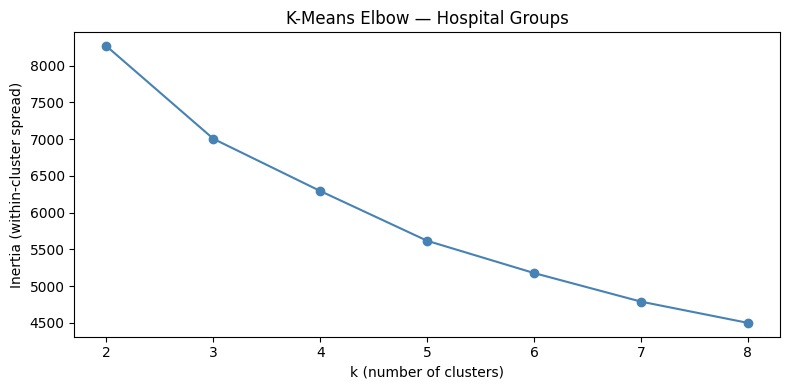

In [18]:
# elbow plot — look for where the curve flattens to pick k
inertias = []
for n in range(2, 9):
    km = KMeans(n_clusters = n, random_state = 42, n_init = 10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize = (8, 4))
plt.plot(range(2, 9), inertias, "o-", color = "steelblue")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (within-cluster spread)")
plt.title("K-Means Elbow — Hospital Groups")
plt.tight_layout()
plt.show()

In [19]:
km = KMeans(n_clusters = 5, random_state = 42, n_init = 10)
df["cluster_label"] = km.fit_predict(X)

print(df["cluster_label"].value_counts().sort_index())

# median rate profile per cluster — like group_by(cluster) %>% summarise(across(everything(), median))
df.groupby("cluster_label")[rate_kpi].median().round(4)

cluster_label
0    198
1    331
2    261
3      9
4    140
Name: count, dtype: int64


,initial_adr_rate_2025,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,member_appeal_rate,initial_adr_rate_2026
cluster_label,,,,,,,,
0,0.3571,0.2043,0.3062,0.0098,0.0305,0.7011,0.0214,0.3502
1,0.2477,0.1266,0.3818,0.0121,0.0213,0.6282,0.0243,0.2666
2,0.2406,0.1237,0.4018,0.0118,0.0208,0.5547,0.0123,0.2634
3,0.2130,0.1103,0.4587,0.0063,0.0227,0.6110,0.4073,0.2254
4,0.1378,0.0693,0.3280,0.0159,0.0234,0.3697,0.0223,0.1783


Variance explained: PC1 = 30.3%, PC2 = 25.4%


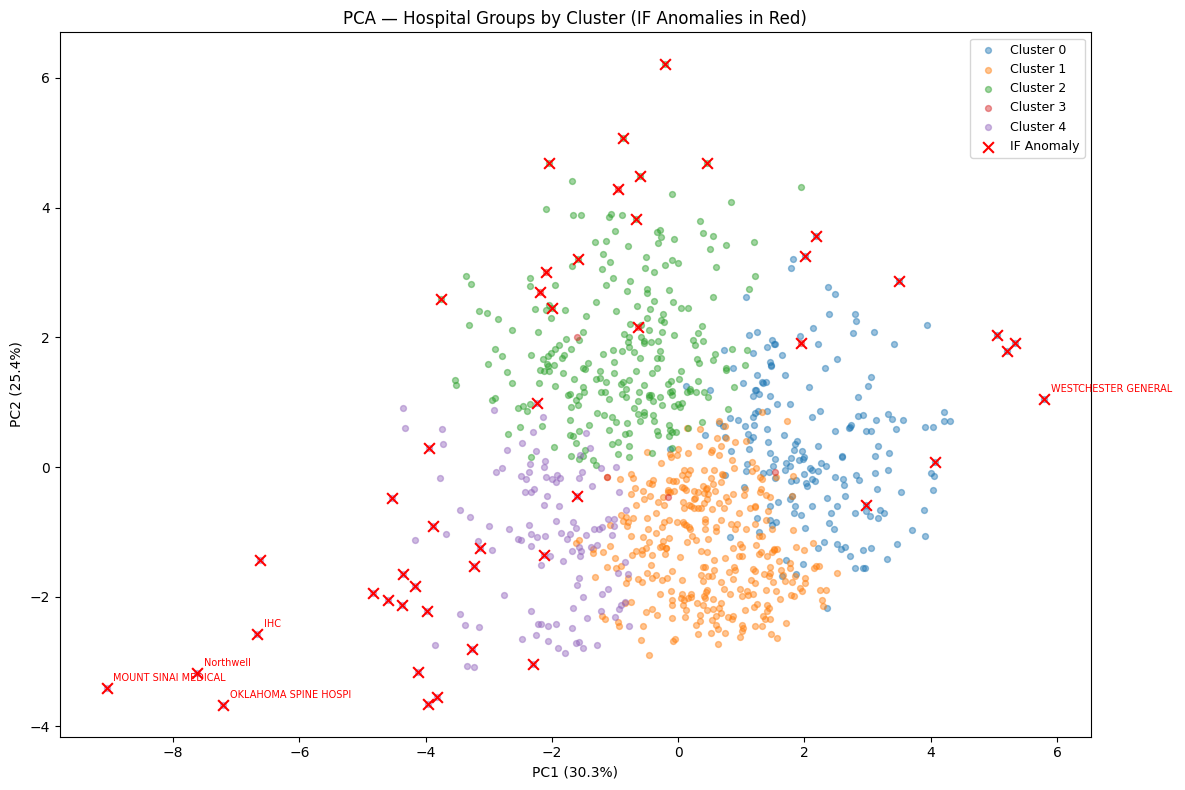

In [20]:
pca = PCA(n_components = 2)
pcs = pca.fit_transform(X)
df["pc1"] = pcs[:, 0]
df["pc2"] = pcs[:, 1]
print(f"Variance explained: PC1 = {pca.explained_variance_ratio_[0]:.1%}, PC2 = {pca.explained_variance_ratio_[1]:.1%}")

fig, ax = plt.subplots(figsize = (12, 8))
colors = plt.cm.tab10(range(5))

for n in range(5):
    sub = df[df["cluster_label"] == n]
    ax.scatter(sub["pc1"], sub["pc2"], color = colors[n], alpha = 0.45, s = 18, label = f"Cluster {n}")

# IF anomalies on top as red X
sub = df[df["anomaly_flag"]]
ax.scatter(sub["pc1"], sub["pc2"], color = "red", marker = "x", s = 60, linewidths = 1.5,
           label = "IF Anomaly", zorder = 5)

# name the top 5 most anomalous
for _, row in df.nsmallest(5, "anomaly_score").iterrows():
    ax.annotate(str(row["hospital_group"])[:20], (row["pc1"], row["pc2"]),
                fontsize = 7, color = "red", xytext = (5, 5), textcoords = "offset points")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA — Hospital Groups by Cluster (IF Anomalies in Red)")
ax.legend(loc = "upper right", fontsize = 9)
plt.tight_layout()
plt.show()

In [21]:
pca.components_

array([[-0.30800104, -0.13486658, -0.15388012,  0.48108286,  0.46200641,
        -0.05230807, -0.22656848,  0.07596319,  0.42700464,  0.01843009,
         0.41936164],
       [ 0.48703245,  0.57287562,  0.56044095,  0.19254026,  0.16211382,
         0.02267276, -0.10431779,  0.00933375,  0.10602941, -0.00946097,
         0.1853405 ]])

## Section D — Within-Market IF

Re-run IF inside each market, so hospitals are compared to their regional peers
instead of the whole country. Bayes shrinkage is recomputed with the MARKET rate
as the prior. Contamination is 10% here because markets are small (~20-60 hospitals).

In [22]:
# only markets with enough hospitals for a within-market model
market_sizes = df["fin_market"].value_counts()
big_markets = market_sizes[market_sizes >= 20].index.tolist()
print(f"Markets with >= 20 hospitals: {len(big_markets)}")

# like group_by(fin_market) %>% group_map(~ fit IF on each group)
local_pieces = []
for mkt in big_markets:
    sub = df[df["fin_market"] == mkt].copy()

    # market-level rates = the new prior for shrinkage
    m_initial_adr_2025 = sub["initial_adr_cnt_2025"].sum() / sub["case_count_2025"].sum()
    m_persistent_adr   = sub["persistent_adr_cnt"].sum()   / sub["case_count_2025"].sum()
    m_p2p_overturn     = sub["p2p_ovrtn_cnt"].sum()         / sub["initial_adr_cnt_2025"].sum()
    m_appeal_overturn  = sub["appeal_ovrtn_cnt"].sum()       / sub["initial_adr_cnt_2025"].sum()
    m_mcr_overturn     = sub["mcr_ovrtn_cnt"].sum()          / sub["initial_adr_cnt_2025"].sum()
    m_md_review        = sub["md_reviewed_cnt"].sum()        / sub["case_count_2025"].sum()
    m_member_appeal    = sub["member_appeal_cnt"].sum()      / sub["initial_adr_cnt_2026"].sum()
    m_initial_adr_2026 = sub["initial_adr_cnt_2026"].sum()  / sub["case_count_2026"].sum()

    sub = (
        sub
        .assign(
            initial_adr_rate_2025 = lambda x: (x.initial_adr_cnt_2025 + k * m_initial_adr_2025) / (x.case_count_2025 + k),
            persistent_adr_rate   = lambda x: (x.persistent_adr_cnt   + k * m_persistent_adr)   / (x.case_count_2025 + k),
            p2p_overturn_rate     = lambda x: (x.p2p_ovrtn_cnt         + k * m_p2p_overturn)     / (x.initial_adr_cnt_2025 + k),
            appeal_overturn_rate  = lambda x: (x.appeal_ovrtn_cnt       + k * m_appeal_overturn)  / (x.initial_adr_cnt_2025 + k),
            mcr_overturn_rate     = lambda x: (x.mcr_ovrtn_cnt          + k * m_mcr_overturn)     / (x.initial_adr_cnt_2025 + k),
            md_review_rate        = lambda x: (x.md_reviewed_cnt        + k * m_md_review)        / (x.case_count_2025 + k),
            member_appeal_rate    = lambda x: (x.member_appeal_cnt      + k * m_member_appeal)    / (x.initial_adr_cnt_2026 + k),
            initial_adr_rate_2026 = lambda x: (x.initial_adr_cnt_2026  + k * m_initial_adr_2026) / (x.case_count_2026 + k)
        )
    )

    X_sub = StandardScaler().fit_transform(sub[iso_kpi])
    iso_sub = IsolationForest(contamination = 0.10, n_estimators = 200, random_state = 42)
    iso_sub.fit(X_sub)

    sub["local_anomaly_score"] = iso_sub.decision_function(X_sub)
    sub["local_anomaly_flag"]  = iso_sub.predict(X_sub) == -1
    local_pieces.append(sub[["hospital_group", "fin_market", "local_anomaly_score", "local_anomaly_flag"]])

# stack the per-market results back together — like bind_rows()
df_local = pd.concat(local_pieces, ignore_index = True)
df = df.merge(df_local, on = ["hospital_group", "fin_market"], how = "left")
df["local_anomaly_flag"] = df["local_anomaly_flag"].fillna(False)

print(f"Locally flagged: {df['local_anomaly_flag'].sum()}")

Markets with >= 20 hospitals: 19
Locally flagged: 75


In [23]:
# 2x2: who's an outlier nationally vs. within their own market?
# "both" = strongest signal; "local only" = hidden by national averages
pd.crosstab(
    df["anomaly_flag"].map({True: "national outlier", False: "national normal"}),
    df["local_anomaly_flag"].map({True: "local outlier", False: "local normal"}),
    margins = True
)

local_anomaly_flag,local normal,local outlier,All
anomaly_flag,,,
national normal,850,42,892
national outlier,14,33,47
All,864,75,939


In [24]:
# the interesting quadrant: local outliers that the national model missed
(
    df
    .query("local_anomaly_flag == True and anomaly_flag == False")
    .sort_values("local_anomaly_score")
    [["hospital_group", "fin_market", "case_count_2025", *rate_kpi, "local_anomaly_score"]]
    .round(4)
    .head(20)
)

,hospital_group,fin_market,case_count_2025,initial_adr_rate_2025,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,member_appeal_rate,initial_adr_rate_2026,local_anomaly_score
561,Maury Regional,TN,1139,0.0614,0.0296,0.3731,0.0718,0.0303,0.1535,0.0099,0.2433,-0.0996
697,Christ Hospital,OH,2317,0.1221,0.0457,0.4294,0.0978,0.0133,0.3661,0.0100,0.1268,-0.0617
897,SSM Health Missouri,MO,10579,0.2692,0.1226,0.4862,0.0096,0.0357,0.6287,0.1128,0.3201,-0.0446
724,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,VA,194,0.1064,0.0584,0.3658,0.0151,0.0213,0.3545,0.1223,0.1841,-0.0413
258,University of Toledo,OH,567,0.0826,0.0539,0.2856,0.0109,0.0153,0.1661,0.0247,0.0774,-0.0406
154,Mt Sinai (NY),NY,3166,0.2892,0.1801,0.2453,0.0743,0.0107,0.5023,0.0669,0.3283,-0.0398
257,UVA Health System,VA,1850,0.1489,0.0822,0.3284,0.0529,0.0385,0.3560,0.0077,0.1711,-0.0367
588,UAB Health System,AL,6125,0.0738,0.0399,0.3672,0.0222,0.0210,0.1863,0.0065,0.1401,-0.0363
188,MEDICAL UNIVERSITY HOSPITAL AUTHORITY-MUSC,GA,497,0.1023,0.0370,0.4619,0.0316,0.0252,0.3172,0.0219,0.1636,-0.0352
684,St. Luke's St. Louis Health System,MO,2966,0.1814,0.1446,0.1084,0.0017,0.0040,0.4889,0.0068,0.1848,-0.0311


In [25]:
# local outliers and the national outliers 
(
    df
    .query("local_anomaly_flag == True and anomaly_flag == True")
    .sort_values("local_anomaly_score")
    [["hospital_group", "fin_market", "case_count_2025", *rate_kpi, "local_anomaly_score"]]
    .round(4)
    .head(20)
)

,hospital_group,fin_market,case_count_2025,initial_adr_rate_2025,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,member_appeal_rate,initial_adr_rate_2026,local_anomaly_score
357,ADVOCATE HEALTH & HOSPITALS IL,IL,8747,0.0126,0.0055,0.3048,0.1608,0.0159,0.0222,0.0328,0.0182,-0.1701
539,Northwell,NY,7944,0.0047,0.0008,0.2423,0.3548,0.0180,0.0033,0.0239,0.0114,-0.1662
845,MOUNT SINAI MEDICAL CENTER OF FLORIDA,FL,5515,0.0149,0.0011,0.1522,0.5948,0.0113,0.0053,0.0216,0.0122,-0.1552
931,OKLAHOMA SPINE HOSPITAL,OK,1286,0.0606,0.0099,0.1547,0.4619,0.0115,0.0453,0.0263,0.0490,-0.1181
654,ETHICUS HOSPITAL DFW,TX,216,0.1014,0.0310,0.2833,0.2149,0.0210,0.1108,0.0259,0.1821,-0.1166
352,ASH,AR,194,0.0900,0.0420,0.3069,0.0161,0.0894,0.1618,0.0534,0.1854,-0.1146
642,WESTCHESTER GENERAL HOSPITAL,FL,114,0.5547,0.3674,0.1815,0.0075,0.0803,0.6066,0.0798,0.5563,-0.1072
934,Stanford Health Hospital,CA-N,1177,0.0815,0.0304,0.3291,0.1664,0.0316,0.1406,0.0416,0.0890,-0.1013
885,Nassau Health,NY,128,0.4886,0.2542,0.1873,0.0077,0.0989,0.6544,0.1787,0.4047,-0.0780
493,Mosaic Life Care,MO,556,0.0379,0.0235,0.3511,0.0158,0.0224,0.1097,0.0236,0.0451,-0.0493


## Section E — Market-Level IF + KS Test

Roll everything up to the market level: which MARKETS look anomalous as a whole?
Then a KS test per market x feature checks whether each market's distribution of
hospital rates is statistically different from the national distribution.

In [26]:
# market profile = median of its hospitals' adjusted rates
df_market = (
    df
    .groupby("fin_market")[iso_kpi]
    .median()
    .reset_index()
)

X_market = StandardScaler().fit_transform(df_market[iso_kpi])
iso_market = IsolationForest(contamination = 0.10, n_estimators = 200, random_state = 42)
iso_market.fit(X_market)

df_market = (
    df_market
    .assign(
        market_anomaly_score = iso_market.decision_function(X_market),
        market_anomaly_flag  = iso_market.predict(X_market) == -1
    )
)

print(f"Markets flagged: {df_market['market_anomaly_flag'].sum()} of {len(df_market)}")
(
    df_market
    .sort_values("market_anomaly_score")
    [["fin_market", *rate_kpi, "market_anomaly_score", "market_anomaly_flag"]]
    .round(4)
    .head(15)
)

Markets flagged: 5 of 49


,fin_market,initial_adr_rate_2025,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,member_appeal_rate,initial_adr_rate_2026,market_anomaly_score,market_anomaly_flag
5,CO,0.2091,0.0897,0.3936,0.0250,0.0165,0.3844,0.0115,0.2328,-0.0806,True
36,OR,0.1529,0.0843,0.2996,0.0117,0.0314,0.4961,0.0164,0.1560,-0.0534,True
43,UT,0.1782,0.0728,0.4084,0.0623,0.0227,0.3691,0.0165,0.2300,-0.0381,True
21,ME,0.2723,0.1279,0.3916,0.0319,0.0325,0.5550,0.0257,0.2865,-0.0319,True
18,LA,0.2739,0.1557,0.2926,0.0116,0.0298,0.6558,0.0358,0.2490,-0.0002,True
11,HI,0.1348,0.0747,0.3308,0.0201,0.0139,0.6932,0.0222,0.1968,0.0000,False
4,CA-S,0.2923,0.1629,0.2510,0.0116,0.0545,0.5175,0.0249,0.3006,0.0034,False
13,ID,0.1340,0.0747,0.3913,0.0153,0.0216,0.3993,0.0243,0.1890,0.0112,False
41,TN,0.3261,0.1694,0.3975,0.0060,0.0201,0.6560,0.0125,0.2926,0.0208,False
29,NE,0.1946,0.1103,0.3405,0.0111,0.0170,0.6382,0.0159,0.2119,0.0318,False


In [27]:
# KS test: is this market's distribution of hospital rates different from the nation's?
# (two nested loops — like crossing(market, feature) %>% map(~ ks.test(...)))
ks_rows = []
for mkt in big_markets:
    sub = df[df["fin_market"] == mkt]
    for col in rate_kpi:
        stat, p = ks_2samp(sub[col], df[col])
        ks_rows.append({
            "fin_market": mkt,
            "feature": col,
            "ks_stat": stat,
            "p_value": p,
            "market_median": sub[col].median(),
            "national_median": df[col].median()
        })

df_ks = (
    pd.DataFrame(ks_rows)
    .assign(
        direction   = lambda x: np.where(x.market_median > x.national_median, "high", "low"),
        significant = lambda x: x.p_value < 0.05
    )
)

print(f"Significant market-feature combos (p < 0.05): {df_ks['significant'].sum()} of {len(df_ks)}")
(
    df_ks
    .query("significant == True")
    .sort_values("ks_stat", ascending = False)
    .round(4)
    .head(30)
)

Significant market-feature combos (p < 0.05): 41 of 152


,fin_market,feature,ks_stat,p_value,market_median,national_median,direction,significant
132,CA-N,mcr_overturn_rate,0.6003,0.0000,0.0445,0.0226,high,True
76,CA-S,mcr_overturn_rate,0.5574,0.0000,0.0545,0.0226,high,True
74,CA-S,p2p_overturn_rate,0.4957,0.0000,0.2510,0.3672,low,True
115,TN,appeal_overturn_rate,0.4147,0.0004,0.0060,0.0121,low,True
23,IL,initial_adr_rate_2026,0.3895,0.0000,0.3340,0.2711,high,True
144,VA,initial_adr_rate_2025,0.3855,0.0040,0.2183,0.2499,low,True
118,TN,member_appeal_rate,0.3817,0.0014,0.0125,0.0203,low,True
12,TX,mcr_overturn_rate,0.3801,0.0000,0.0398,0.0226,high,True
112,TN,initial_adr_rate_2025,0.3458,0.0053,0.3261,0.2499,high,True
113,TN,persistent_adr_rate,0.3300,0.0090,0.1694,0.1293,high,True


## Section F — Monthly Trend Detection

The IF models are snapshots. Here we fit a straight line through each hospital's
monthly rates (202301+) and flag hospitals whose slope is in the worst 5% — an early
warning list of hospitals heading toward anomalous territory.

Note: member_appeal is excluded (only exists from 202601, too short for a trend).

In [28]:
# keep only hospitals in our main eligible table — like semi_join()
df_monthly = df_monthly.merge(df[["hospital_group", "fin_market"]], on = ["hospital_group", "fin_market"], how = "inner")

# month_index = 1, 2, 3, ... so the regression x-axis is evenly spaced
df_monthly["month_index"] = df_monthly["hce_admit_month"].rank(method = "dense").astype(int)

# Bayes shrinkage at monthly grain — k = 20 (smaller, monthly volumes are smaller)
k_month = 20
gm_initial_adr    = df_monthly["initial_adr_cnt"].sum()   / df_monthly["case_count"].sum()
gm_persistent_adr = df_monthly["persistent_adr_cnt"].sum() / df_monthly["case_count"].sum()
gm_p2p_overturn   = df_monthly["p2p_ovrtn_cnt"].sum()      / df_monthly["initial_adr_cnt"].sum()
gm_appeal_overturn= df_monthly["appeal_ovrtn_cnt"].sum()    / df_monthly["initial_adr_cnt"].sum()
gm_mcr_overturn   = df_monthly["mcr_ovrtn_cnt"].sum()       / df_monthly["initial_adr_cnt"].sum()
gm_md_review      = df_monthly["md_reviewed_cnt"].sum()     / df_monthly["case_count"].sum()

df_monthly = (
    df_monthly
    .assign(
        initial_adr_rate     = lambda x: (x.initial_adr_cnt   + k_month * gm_initial_adr)     / (x.case_count + k_month),
        persistent_adr_rate  = lambda x: (x.persistent_adr_cnt + k_month * gm_persistent_adr) / (x.case_count + k_month),
        p2p_overturn_rate    = lambda x: (x.p2p_ovrtn_cnt      + k_month * gm_p2p_overturn)   / (x.initial_adr_cnt + k_month),
        appeal_overturn_rate = lambda x: (x.appeal_ovrtn_cnt    + k_month * gm_appeal_overturn)/ (x.initial_adr_cnt + k_month),
        mcr_overturn_rate    = lambda x: (x.mcr_ovrtn_cnt       + k_month * gm_mcr_overturn)   / (x.initial_adr_cnt + k_month),
        md_review_rate       = lambda x: (x.md_reviewed_cnt     + k_month * gm_md_review)      / (x.case_count + k_month)
    )
)

print(f"Monthly rows after filter: {df_monthly.shape}")
df_monthly.head()

Monthly rows after filter: (12392, 17)


,hospital_group,fin_market,hce_admit_month,case_count,initial_adr_cnt,persistent_adr_cnt,p2p_ovrtn_cnt,appeal_ovrtn_cnt,mcr_ovrtn_cnt,md_reviewed_cnt,month_index,initial_adr_rate,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate
0,Ascension Health Florida,FL,202405,1,1,1,0,0,0,NaN,17,0.275505,0.166697,0.350497,0.018399,0.025968,NaN
1,CLEVELAND CLINIC MARTIN HEALTH_FL,FL,202309,1,1,1,0,0,0,NaN,9,0.275505,0.166697,0.350497,0.018399,0.025968,NaN
2,Wellstar Health System,GA,202411,1,0,0,0,0,0,NaN,23,0.227886,0.119078,0.368022,0.019319,0.027266,NaN
3,North Kansas City Hospital,KS,202412,1,0,0,0,0,0,1.0,24,0.227886,0.119078,0.368022,0.019319,0.027266,0.551835
4,WELLINGTON PHYS ALLIANCES,FL,202412,1,0,0,0,0,0,NaN,24,0.227886,0.119078,0.368022,0.019319,0.027266,NaN


In [ ]:
# fit a line per hospital per KPI — slope = direction of travel
# like group_by(hospital) %>% group_map(~ lm(rate ~ month, .x))
monthly_kpi = ["initial_adr_rate", "persistent_adr_rate", "p2p_overturn_rate",
               "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate"]

slope_rows = []
for (hosp, mkt), grp in df_monthly.groupby(["hospital_group", "fin_market"]):
    if len(grp) < 6:  # need at least 6 months for a meaningful slope
        continue
    grp = grp.sort_values("month_index")
    row = {"hospital_group": hosp, "fin_market": mkt, "n_months": len(grp)}
    for col in monthly_kpi:
        result = linregress(grp["month_index"], grp[col])
        row[col + "_slope"] = result.slope
    slope_rows.append(row)

df_slopes = pd.DataFrame(slope_rows)
print(f"Hospitals with slopes: {len(df_slopes)}")

# worsening = ADR/MD-review rising, or overturn rates falling (overturns dropping
# means denials are sticking more)
df_slopes = (
    df_slopes
    .assign(
        initial_adr_worsening     = lambda x: x.initial_adr_rate_slope     >= x.initial_adr_rate_slope.quantile(0.95),
        persistent_adr_worsening  = lambda x: x.persistent_adr_rate_slope  >= x.persistent_adr_rate_slope.quantile(0.95),
        md_review_worsening       = lambda x: x.md_review_rate_slope       >= x.md_review_rate_slope.quantile(0.95),
        p2p_overturn_worsening    = lambda x: x.p2p_overturn_rate_slope    <= x.p2p_overturn_rate_slope.quantile(0.05),
        appeal_overturn_worsening = lambda x: x.appeal_overturn_rate_slope <= x.appeal_overturn_rate_slope.quantile(0.05),
        mcr_overturn_worsening    = lambda x: x.mcr_overturn_rate_slope    <= x.mcr_overturn_rate_slope.quantile(0.05)
    )
)

worsening_cols = ["initial_adr_worsening", "persistent_adr_worsening", "md_review_worsening",
                  "p2p_overturn_worsening", "appeal_overturn_worsening", "mcr_overturn_worsening"]
df_slopes["trend_flag"]       = df_slopes[worsening_cols].any(axis = 1)
df_slopes["trend_flag_count"] = df_slopes[worsening_cols].sum(axis = 1)

print(f"Hospitals with any worsening trend: {df_slopes['trend_flag'].sum()}")
(
    df_slopes
    .query("trend_flag == True")
    .sort_values("trend_flag_count", ascending = False)
    .round(5)
    .head(20)
)





Hospitals with slopes: 939
Hospitals with any worsening trend: 198


,hospital_group,fin_market,n_months,initial_adr_rate_slope,persistent_adr_rate_slope,p2p_overturn_rate_slope,appeal_overturn_rate_slope,mcr_overturn_rate_slope,md_review_rate_slope,initial_adr_worsening,persistent_adr_worsening,md_review_worsening,p2p_overturn_worsening,appeal_overturn_worsening,mcr_overturn_worsening,trend_flag,trend_flag_count
842,UNIVERSITY HEALTHCARE SYSTEM,LA,12,0.00271,0.00958,-0.00950,-0.00039,-0.00298,0.01393,False,True,True,True,False,True,True,4
869,University of California Davis (UCD),CA-N,12,0.00748,0.00674,-0.00157,0.00850,-0.00581,0.01676,True,True,True,False,False,True,True,4
224,Dignity Health System Hospital,CA-S,13,0.00254,0.00840,-0.00536,-0.00032,-0.00574,0.01619,False,True,True,False,False,True,True,3
236,EMANATE HEALTH,CA-S,13,0.00863,0.01042,-0.00453,-0.00025,0.00084,0.02064,True,True,True,False,False,False,True,3
3,AHMC,CA-S,12,0.01058,0.00659,-0.00425,-0.00110,-0.00063,0.02099,True,True,True,False,False,False,True,3
202,Cox Health Systems,NY,12,0.00690,0.00755,0.00280,-0.00239,0.00039,-0.01576,True,True,False,False,True,False,True,3
772,St. Johns Riverside,NY,12,0.00681,0.00890,-0.00105,-0.00022,-0.00375,0.00116,True,True,False,False,False,True,True,3
912,WESTCHESTER GENERAL HOSPITAL,FL,12,0.00830,0.01692,-0.00428,-0.00022,-0.00251,0.01136,True,True,False,False,False,True,True,3
866,University Of New Mexico,NM,12,0.00809,0.00730,-0.00367,-0.00026,0.00088,0.01825,True,True,True,False,False,False,True,3
810,TORRANCE MEMORIAL MEDICAL CENTER,CA-S,12,0.01235,0.00819,0.00280,0.00122,-0.00130,0.02745,True,True,True,False,False,False,True,3


In [ ]:
df_slopes

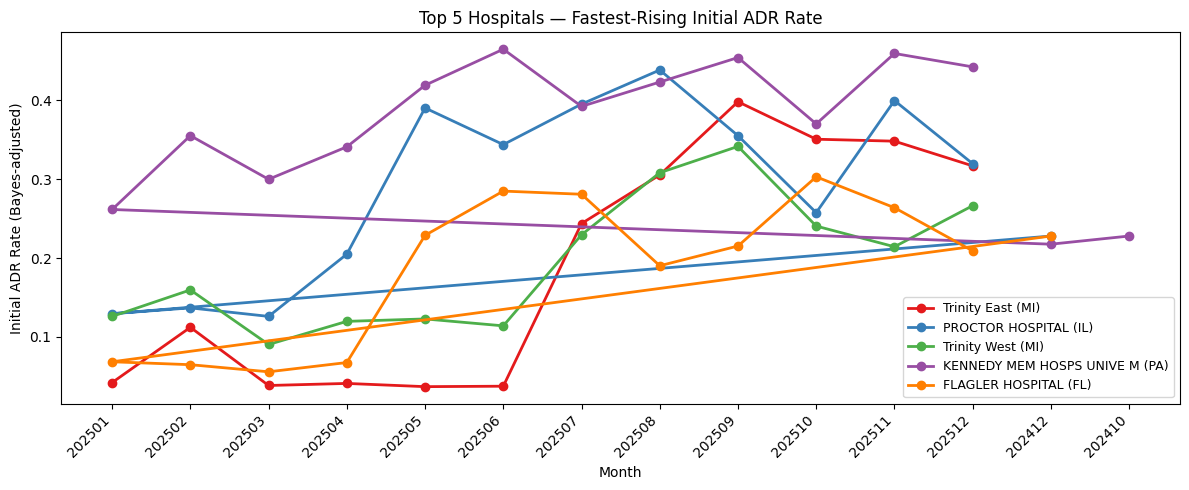

In [30]:
# the 5 hospitals with the fastest-rising ADR rate, plotted over time
top5_trend = df_slopes.nlargest(5, "initial_adr_rate_slope")

fig, ax = plt.subplots(figsize = (12, 5))
colors = plt.cm.Set1(range(5))

for i, (_, row) in enumerate(top5_trend.iterrows()):
    grp = (
        df_monthly
        .query("hospital_group == @row.hospital_group and fin_market == @row.fin_market")
        .sort_values("hce_admit_month")
    )
    ax.plot(grp["hce_admit_month"].astype(str), grp["initial_adr_rate"],
            marker = "o", linewidth = 2, color = colors[i],
            label = f"{str(row['hospital_group'])[:25]} ({row['fin_market']})")

ax.set_xlabel("Month")
ax.set_ylabel("Initial ADR Rate (Bayes-adjusted)")
ax.set_title("Top 5 Hospitals — Fastest-Rising Initial ADR Rate")
ax.legend(fontsize = 9)
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

## Section G — Nearest-Neighbor Peer Group

For each flagged hospital, find the 5 most similar NON-flagged hospitals (same feature
space the IF used). "This hospital looks like these 5 normal ones, except for X" —
useful for investigating and packaging the anomalies.

In [31]:
df_flagged = df[df["anomaly_flag"]].reset_index(drop = True)
df_normal  = df[~df["anomaly_flag"]].reset_index(drop = True)

# scale on the full population so flagged and normal are on the same scale
X_flagged = scaler.transform(df_flagged[iso_kpi])
X_normal  = scaler.transform(df_normal[iso_kpi])

nn = NearestNeighbors(n_neighbors = 5)
nn.fit(X_normal)
distances, neighbor_idx = nn.kneighbors(X_flagged)

# one row per flagged hospital: its rates vs. the mean of its 5 peers
peer_rows = []
for i in range(len(df_flagged)):
    peers = df_normal.iloc[neighbor_idx[i]]
    row = {
        "hospital_group":    df_flagged.loc[i, "hospital_group"],
        "fin_market":        df_flagged.loc[i, "fin_market"],
        "anomaly_rank":      df_flagged.loc[i, "anomaly_rank"],
        "reason":            df_flagged.loc[i, "reason"],
        "avg_peer_distance": distances[i].mean(),
        "peer_1": peers.iloc[0]["hospital_group"],
        "peer_2": peers.iloc[1]["hospital_group"],
        "peer_3": peers.iloc[2]["hospital_group"]
    }
    for col in rate_kpi:
        row["entity_" + col] = df_flagged.loc[i, col]
        row["peers_" + col]  = peers[col].mean()
        row["diff_" + col]   = df_flagged.loc[i, col] - peers[col].mean()
    peer_rows.append(row)

df_peers = pd.DataFrame(peer_rows).sort_values("anomaly_rank")
diff_cols = ["diff_" + col for col in rate_kpi]

print(f"Peer comparisons built: {len(df_peers)}")
df_peers[["hospital_group", "fin_market", "anomaly_rank", "reason",
          "avg_peer_distance", *diff_cols]].round(4).head(15)

Peer comparisons built: 47


,hospital_group,fin_market,anomaly_rank,reason,avg_peer_distance,diff_initial_adr_rate_2025,diff_persistent_adr_rate,diff_p2p_overturn_rate,diff_appeal_overturn_rate,diff_mcr_overturn_rate,diff_md_review_rate,diff_member_appeal_rate,diff_initial_adr_rate_2026
41,MOUNT SINAI MEDICAL CENTER OF FLORIDA,FL,1,appeal_overturn_rate (high),12.8258,-0.2093,-0.0814,-0.1890,0.4301,-0.0123,-0.4134,-0.0008,-0.2049
25,Northwell,NY,2,appeal_overturn_rate (high),7.5620,-0.2194,-0.0817,-0.0989,0.1901,-0.0056,-0.4154,0.0015,-0.2057
45,OKLAHOMA SPINE HOSPITAL,OK,3,appeal_overturn_rate (high),9.2737,-0.1636,-0.0726,-0.1865,0.2972,-0.0121,-0.3734,0.0039,-0.1680
39,IHC,UT,4,appeal_overturn_rate (high),4.8646,-0.1034,-0.0402,-0.0782,0.0899,0.0005,-0.2859,-0.0007,-0.1580
29,WESTCHESTER GENERAL HOSPITAL,FL,5,member_appeal_rate (high),3.4367,0.1185,0.0876,0.0072,-0.0014,0.0199,-0.0910,0.0456,0.1506
13,ADVOCATE HEALTH & HOSPITALS IL,IL,6,appeal_overturn_rate (high),4.0197,-0.0878,-0.0445,-0.0553,0.0908,-0.0065,-0.2173,0.0134,-0.1286
24,Atrium Health System,NC,7,member_appeal_rate (high),8.8453,0.0295,0.0236,0.0352,-0.0006,-0.0102,-0.0220,0.3516,0.0529
16,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,8,member_appeal_rate (high),7.9473,-0.0594,-0.0066,-0.1202,0.0120,-0.0033,-0.1709,0.3072,-0.0404
19,Froedtert,WI,9,mcr_overturn_rate (high),4.8352,-0.0803,-0.0656,-0.1383,0.0022,0.0553,-0.1237,0.0041,-0.0352
32,NMC OPERATING COMPANY,LA,10,appeal_overturn_rate (high),3.6025,-0.1439,-0.0664,-0.0358,0.0557,-0.0006,-0.3415,0.0007,0.0292


## Section H — Export

In [32]:
# bring trend flags onto the main table
df = df.merge(
    df_slopes[["hospital_group", "fin_market", "trend_flag", "trend_flag_count"]],
    on = ["hospital_group", "fin_market"],
    how = "left"
)
df["trend_flag"]       = df["trend_flag"].fillna(False)
df["trend_flag_count"] = df["trend_flag_count"].fillna(0)

output_dir = r"C:\Users\knguy139\Documents\Projects\Data\Output"

df.to_csv(output_dir + r"\loc_if_hospital_group_expanded.csv", index = False)

(
    df
    .query("anomaly_flag == True")
    .sort_values("anomaly_score")
    [["hospital_group", "fin_market", "case_count_2025", "initial_adr_cnt_2025",
      *rate_kpi, "anomaly_score", "anomaly_rank", "reason",
      "ensemble_score", "ensemble_flag", "cluster_label",
      "local_anomaly_flag", "trend_flag", "trend_flag_count"]]
    .round(4)
    .to_csv(output_dir + r"\loc_if_hospital_group_flagged_expanded.csv", index = False)
)

df_market.to_csv(output_dir + r"\loc_if_market_summary.csv", index = False)
df_ks.to_csv(output_dir + r"\loc_if_market_ks_test.csv", index = False)
df_slopes.to_csv(output_dir + r"\loc_if_trend_flags.csv", index = False)
df_peers.to_csv(output_dir + r"\loc_if_peer_comparison.csv", index = False)

print(f"Exported 6 files to {output_dir}")

Exported 6 files to C:\Users\knguy139\Documents\Projects\Data\Output


## Section I — Changepoint Detection

The trend section fits straight lines, but hospitals usually don't drift — they SHIFT
abruptly (new UM vendor, staffing change, policy change). Here we find the single
biggest level shift in each hospital's monthly ADR rate and when it happened.
The "when" is the actionable part: you can ask what changed at that hospital that month.

One-time install: `pip install ruptures`

In [33]:
import ruptures as rpt

# find the single biggest level shift per hospital — like group_by() %>% group_map()
cp_rows = []
for (hosp, mkt), grp in df_monthly.groupby(["hospital_group", "fin_market"]):
    if len(grp) < 12:  # need enough months on both sides of a potential shift
        continue
    grp = grp.sort_values("month_index")
    y = grp["initial_adr_rate"].values

    # Binseg with n_bkps = 1: "where should I split this series into two levels
    # so the split explains the most variance?"
    algo = rpt.Binseg(model = "l2").fit(y)
    bkp = algo.predict(n_bkps = 1)[0]  # index of the first month AFTER the shift

    # skip shifts at the edges — fewer than 3 months on one side isn't a level, it's noise
    if bkp < 3 or bkp > len(y) - 3:
        continue

    cp_rows.append({
        "hospital_group": hosp,
        "fin_market":     mkt,
        "n_months":       len(grp),
        "cp_month":       grp["hce_admit_month"].iloc[bkp],  # first month of the new level
        "mean_before":    y[:bkp].mean(),
        "mean_after":     y[bkp:].mean()
    })

df_cp = (
    pd.DataFrame(cp_rows)
    .assign(
        level_shift = lambda x: x.mean_after - x.mean_before,
        abs_shift   = lambda x: x.level_shift.abs(),
        pct_shift   = lambda x: x.level_shift / x.mean_before
    )
    .assign(cp_flag = lambda x: x.abs_shift >= x.abs_shift.quantile(0.95))
    .sort_values("abs_shift", ascending = False)
)

print(f"Hospitals with a detectable changepoint: {len(df_cp)}")
print(f"Flagged (top 5% biggest shifts): {df_cp['cp_flag'].sum()}")
df_cp.round(4).head(20)

Hospitals with a detectable changepoint: 914
Flagged (top 5% biggest shifts): 46


,hospital_group,fin_market,n_months,cp_month,mean_before,mean_after,level_shift,abs_shift,pct_shift,cp_flag
801,Trinity East,MI,12,202506,0.0540,0.2858,0.2318,0.2318,4.2912,True
463,MOUNT SINAI MEDICAL CENTER OF FLORIDA,FL,17,202501,0.2239,0.0218,-0.2021,0.2021,-0.9025,True
600,PROCTOR HOSPITAL,IL,13,202505,0.1650,0.3625,0.1975,0.1975,1.1975,True
618,Presence Alexian Health System,IL,22,202501,0.2317,0.4115,0.1798,0.1798,0.7760,True
878,Virtua Hospital,PA,15,202503,0.2517,0.4037,0.1519,0.1519,0.6035,True
250,FLAGLER HOSPITAL,FL,13,202505,0.0968,0.2470,0.1502,0.1502,1.5515,True
608,Peacehealth WA/OR,OR,18,202412,0.2449,0.0951,-0.1498,0.1498,-0.6116,True
469,Maimonides Medical Center,NY,13,202505,0.3192,0.1710,-0.1482,0.1482,-0.4644,True
389,KENNEDY MEM HOSPS UNIVE MED CTR,PA,14,202504,0.2724,0.4186,0.1461,0.1461,0.5365,True
477,McLaren Physician Partners,MI,13,202510,0.0824,0.2264,0.1440,0.1440,1.7477,True


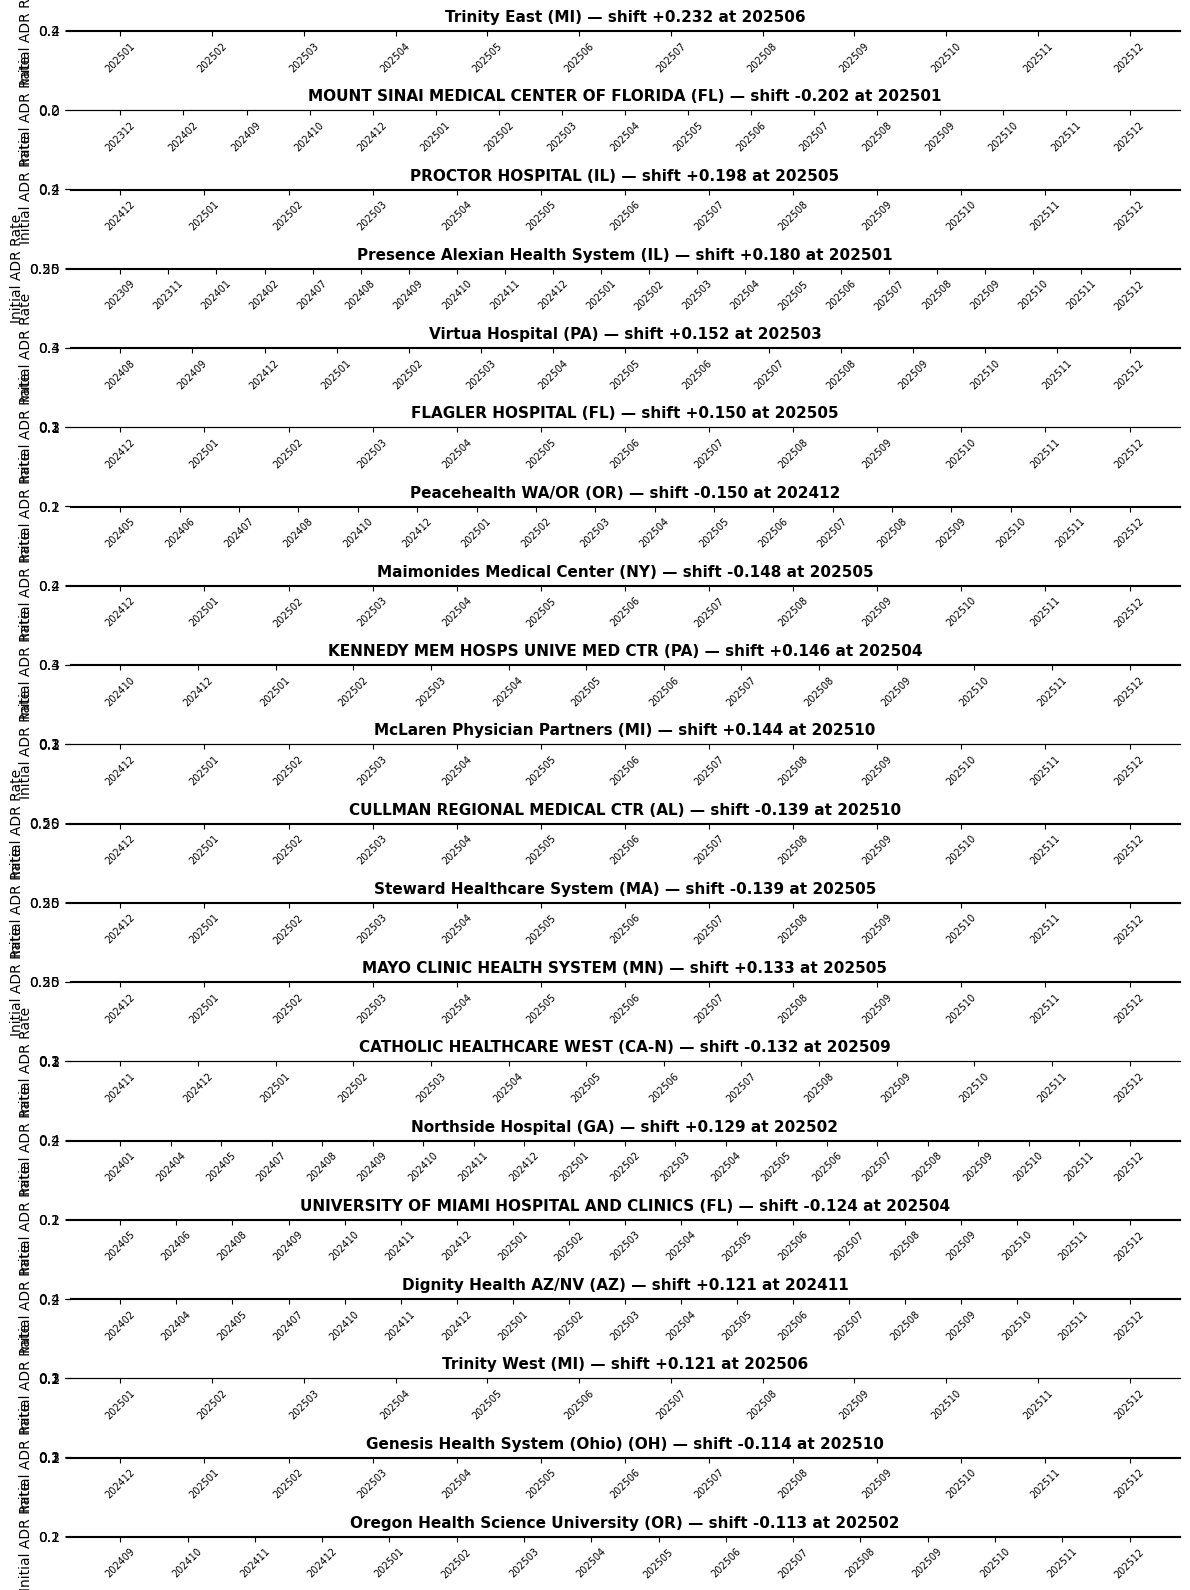

In [ ]:
# the 5 biggest level shifts, plotted — dashed line marks the changepoint month
top5_cp = df_cp.head(5)

fig, axes = plt.subplots(5, 1, figsize = (12, 16))

for ax, (_, row) in zip(axes, top5_cp.iterrows()):
    grp = (
        df_monthly
        .query("hospital_group == @row.hospital_group and fin_market == @row.fin_market")
        .sort_values("hce_admit_month")
    )
    months = grp["hce_admit_month"].astype(str)
    ax.plot(months, grp["initial_adr_rate"], marker = "o", color = "steelblue")
    ax.axvline(str(row["cp_month"]), color = "red", linestyle = "--", linewidth = 1.5)

    # before/after level lines
    before = months < str(row["cp_month"])
    ax.hlines(row["mean_before"], xmin = 0, xmax = before.sum() - 1, color = "gray", linestyle = ":")
    ax.hlines(row["mean_after"], xmin = before.sum(), xmax = len(months) - 1, color = "gray", linestyle = ":")

    ax.set_title(
        f"{str(row['hospital_group'])[:40]} ({row['fin_market']}) — "
        f"shift {row['level_shift']:+.3f} at {row['cp_month']}",
        fontsize = 11, fontweight = "bold"
    )
    ax.set_ylabel("Initial ADR Rate")
    ax.tick_params(axis = "x", rotation = 45, labelsize = 7)

plt.tight_layout()
plt.show()

## Section J — SHAP Driver Attribution

The MAD z-score driver answers "which single feature is most extreme for this hospital?"
SHAP answers a better question: "which features actually pushed THIS hospital's IF score
toward anomalous?" — including hospitals flagged for unusual COMBINATIONS where no
single z-score stands out.

Sign convention: lower IF score = more anomalous, so NEGATIVE SHAP values push toward anomalous.

One-time install: `pip install shap`

In [35]:
import shap

explainer = shap.TreeExplainer(iso)
shap_vals = explainer.shap_values(X)  # one row per hospital, one column per feature

df_shap = pd.DataFrame(shap_vals, columns = iso_kpi, index = df.index)

# the SHAP driver = the feature pushing hardest toward anomalous (most negative)
df["shap_driver"]       = df_shap.idxmin(axis = 1)
df["shap_driver_value"] = df_shap.min(axis = 1)

# how often does SHAP agree with the MAD z-score driver on flagged hospitals?
flagged = df[df["anomaly_flag"]]
agreement = (flagged["shap_driver"] == flagged["driver"]).mean()
print(f"SHAP driver == MAD z driver on flagged hospitals: {agreement:.0%}")

# where they disagree, SHAP is seeing a combination effect the z-score missed
(
    flagged
    .query("shap_driver != driver")
    [["hospital_group", "fin_market", "anomaly_rank", "driver", "shap_driver", "z_score", "shap_driver_value"]]
    .sort_values("anomaly_rank")
    .round(4)
    .head(15)
)

SHAP driver == MAD z driver on flagged hospitals: 85%


,hospital_group,fin_market,anomaly_rank,driver,shap_driver,z_score,shap_driver_value
642,WESTCHESTER GENERAL HOSPITAL,FL,5,member_appeal_rate,persistent_adr_rate,7.1152,-1.6032
130,Ascension MI,MI,13,appeal_overturn_rate,md_review_rate,10.6663,-1.0583
82,HCA INC,FL,17,log_initial_adr_cnt_2025,log_initial_adr_cnt_2026,3.3505,-1.5277
608,Novant Health System,NC,20,p2p_overturn_rate,log_initial_adr_cnt_2026,-2.9930,-1.2461
416,Mercy Health System (OH),OH,41,log_initial_adr_cnt_2025,log_initial_adr_cnt_2026,2.4929,-1.2080
61,Piedmont Health System,GA,42,mcr_overturn_rate,log_case_count_2025,3.0888,-0.9293
735,CATHOLIC HEALTHCARE WEST,CA-N,46,appeal_overturn_rate,mcr_overturn_rate,7.2954,-1.5518


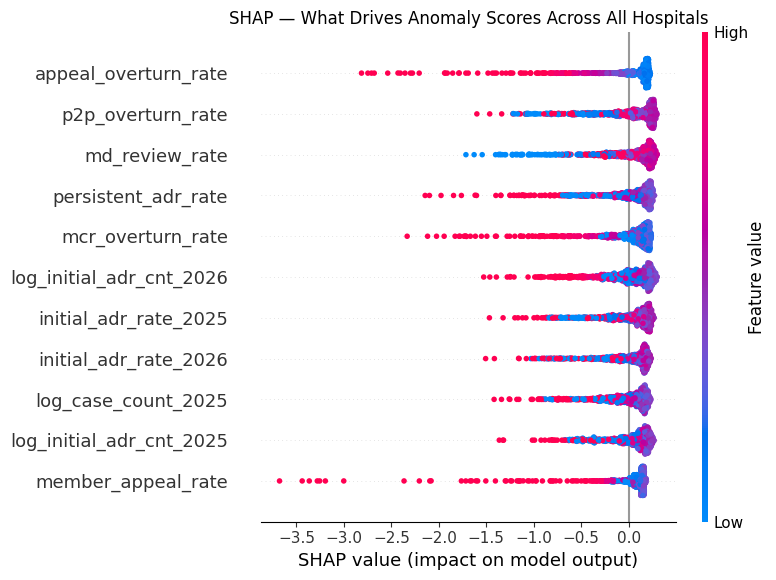

In [36]:
# beeswarm: every hospital's SHAP value per feature.
# points far LEFT = pushing toward anomalous; color = feature value (scaled)
shap.summary_plot(shap_vals, features = X, feature_names = iso_kpi, show = False)
plt.title("SHAP — What Drives Anomaly Scores Across All Hospitals")
plt.tight_layout()
plt.show()

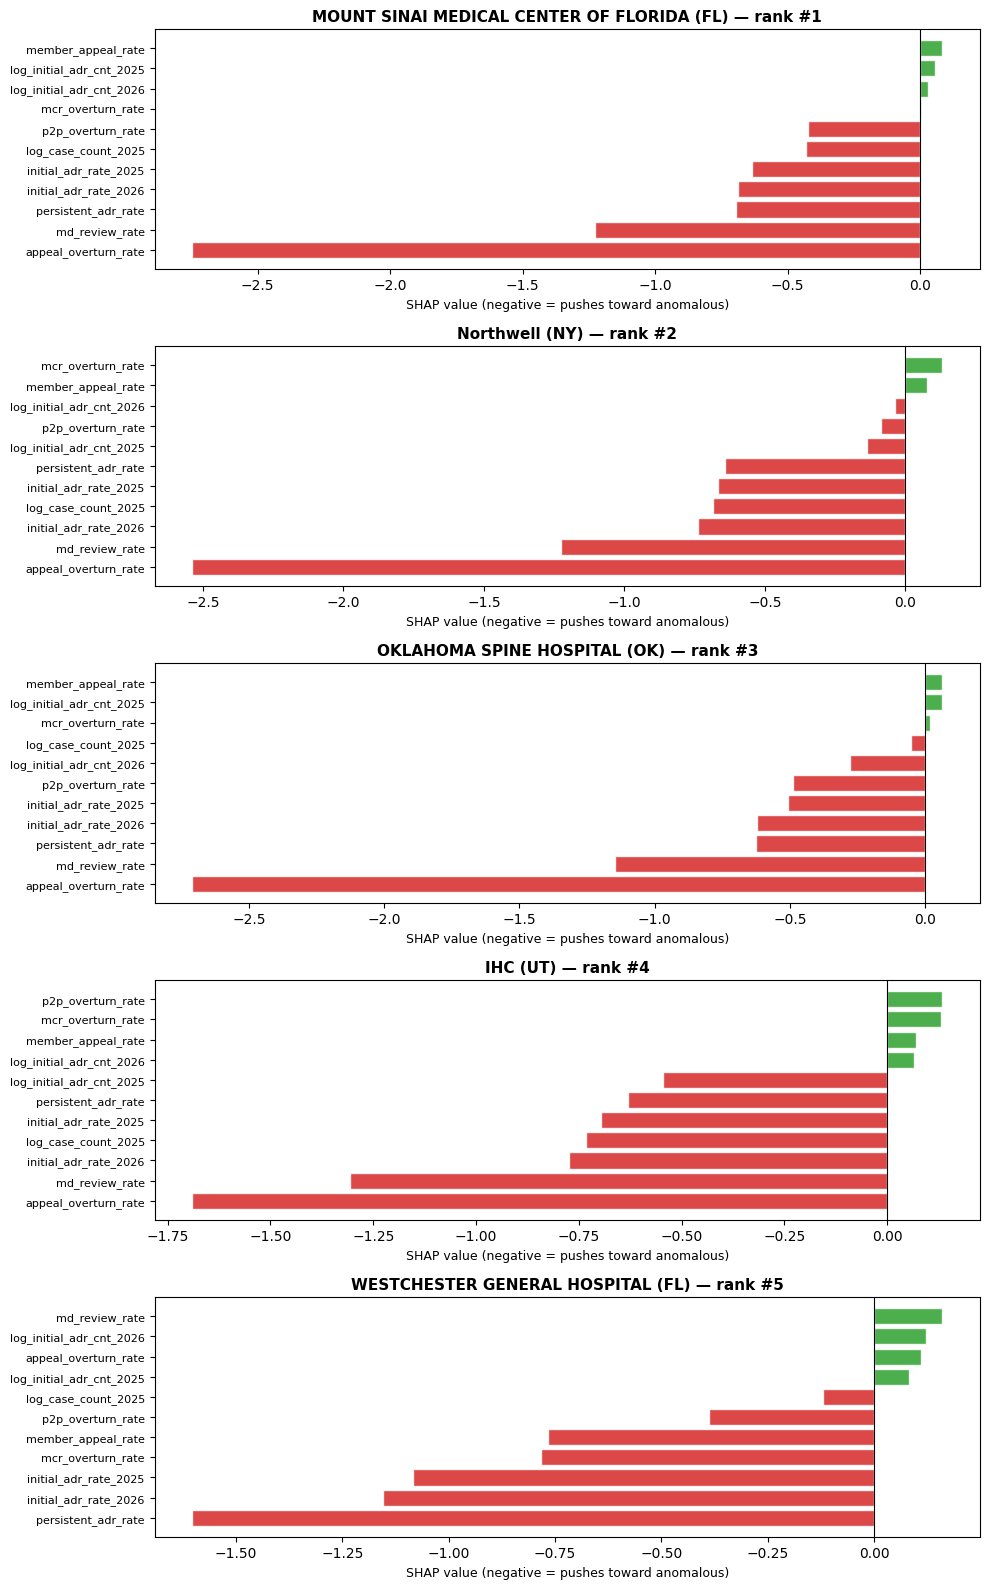

In [37]:
# per-hospital breakdown for the top 5 anomalies — like the deviation bar chart,
# but showing the model's actual reasoning instead of raw deviations
top5_anom = df.nsmallest(5, "anomaly_score")

fig, axes = plt.subplots(5, 1, figsize = (10, 16))

for ax, (idx, row) in zip(axes, top5_anom.iterrows()):
    vals = df_shap.loc[idx].sort_values()
    colors = ["#d62728" if v < 0 else "#2ca02c" for v in vals]
    ax.barh(vals.index, vals.values, color = colors, alpha = 0.85, edgecolor = "white")
    ax.axvline(0, color = "black", linewidth = 0.8)
    ax.set_title(
        f"{str(row['hospital_group'])[:40]} ({row['fin_market']}) — rank #{row['anomaly_rank']}",
        fontsize = 11, fontweight = "bold"
    )
    ax.set_xlabel("SHAP value (negative = pushes toward anomalous)", fontsize = 9)
    ax.tick_params(axis = "y", labelsize = 8)

plt.tight_layout()
plt.show()

In [38]:
# re-export the full table (now includes shap_driver columns) + changepoints
df.to_csv(output_dir + r"\loc_if_hospital_group_expanded.csv", index = False)
df_cp.to_csv(output_dir + r"\loc_if_changepoints.csv", index = False)
print("Re-exported full table + changepoints.")

Re-exported full table + changepoints.
